In [1]:
# Inverse scheme reattack.
# By: Ligang Sun.
# Date: 04/18/2025.
# You reap what you sow.
# Goal of this file: complete the workflow with higher dimension searching space.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jcm_optimizer_path = "/home/sun2024/JCMoptimizer"
sys.path.insert(0, os.path.join(jcm_optimizer_path, "interface", "python"))
from jcmoptimizer import Server, Client, Study, Observation

In [3]:
from forward_model import ForwardModel
from forward_model.modules import ConfigParameter

In [4]:
# Statement of the problem.
thetaarray=np.linspace(-20,30,6) # for now we still use the simple Reference 1.

# source definition: unit m.
lambda0=1e-9 #**********************************check!!
# geometry: unit in m.
pitch=80e-9
line=40e-9
height=30e-9
thickness=1e-3 # substrate with thickness being 1mm.
rr=5 # sample detector distance in m.
# material parameter.
epsilonr1=0.99964+0.0000295399j # grating structure************check!!
epsilonr2=0.999435 # substrate********************check!!

dimqxbranch=7 # number of interested Qx peak per branch.
diroutput="/home/sun2024/Resource/JCM/Inverse_2D/simulation2a/Reference1/Output_all"

config=ConfigParameter(pitch, line, height, thickness, rr, epsilonr1, epsilonr2, lambda0, dimqxbranch)

In [5]:
# Forward model initialization.
fm=ForwardModel(config, Multiplicity=1, NThreads=6)

In [6]:
# Part 1: generate numerical reference.
Qzdomain, intref, intuncertainty =fm.CompRef(thetaarray,config,diroutput)

current thata :  -20.0
matmeta generated.
Numerical reference generated.


In [7]:
# Part 2: intensity with an arbitray initial guess. The real case.
initguess={'cd':27.5, 'h': 33, 'swa': 69, 'r_top': 7.0, 'r_bot':6.0}
intrandom=fm.ModelEvaluate(keys=initguess,config=config)

current thata :  -20.0
current thata :  -10.0
current thata :  0.0
current thata :  10.0
current thata :  20.0
current thata :  30.0
{'IP': '0.0.0.0',
 'Jobs': {'Finished': [],
          'Pending': [],
          'ReceivingData': [],
          'Running': [2031221954],
          'SendingData': [],
          'Waiting': [1520392379, 903756743, 1159098584, 475278047, 499380373]},
 'Port': 45985}
All status {'IP': '0.0.0.0', 'Port': 45985, 'Jobs': {'Finished': [], 'Pending': [], 'ReceivingData': [], 'Running': [2031221954], 'SendingData': [], 'Waiting': [1520392379, 903756743, 1159098584, 475278047, 499380373]}}
All logs saved in /home/sun2024/Resource/JCM/Inverse_2D/simulation2a/forward_model/jcm/logs_all.txt.
matmeta generated.
Forward model evaluated.
Relative error report:
relative error of the 1th peak, 0.06
relative error of the 2th peak, 0.40
relative error of the 3th peak, 0.44
relative error of the 4th peak, 0.31
relative error of the 5th peak, 0.12
relative error of the 6th peak, 0

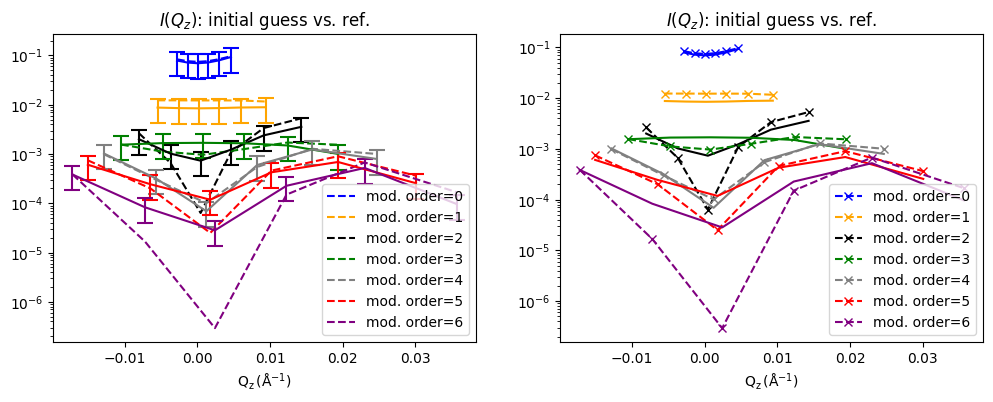

In [11]:
# Initial guess vs. reference.
colorarray=['blue','orange','black','green','gray','red','purple']
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
for i in range(config.dimqxbranch):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intrandom[:,i]
    plt.errorbar(qzarray, intrefarray, yerr=uncertainarray, fmt='-', elinewidth=1.5, capsize=6, capthick=1.5,color=colorarray[i])
    plt.plot(qzarray, intmodarray,'--', markersize=5, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: initial guess vs. ref.')
plt.legend()
#plt.grid()

plt.subplot(1,2,2)
for i in range(intref.shape[1]):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intrandom[:,i]
    plt.plot(qzarray, intrefarray,'-', color=colorarray[i])
    plt.plot(qzarray, intmodarray,'--x', markersize=6, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: initial guess vs. ref.')
plt.legend()
#plt.grid()

plt.show()

In [12]:
# Relative error report:
print("Relative error report:")
rltverrarray=[]
for i in range(config.dimqxbranch):
    array1=intref[:,i]
    array2=intrandom[:,i]
    rltverr=np.linalg.norm(array1-array2)/np.linalg.norm(array1)
    rltverrarray.append(rltverr)
    print(f"relative error of the {i+1}th peak, {rltverr:.2f}")
print(f"Overall relative error: {np.mean(rltverrarray):.2f}")

In [13]:
# Part 3: Bayesian optimization.
#start server and connect client to it
server = Server()
client = Client(server.host)

In [14]:
# define search space.
design_space = [
 {'name': 'cd', 'domain': [25.2, 32]},
 {'name': 'h', 'domain': [27.3, 34]},
{'name': 'swa', 'domain': [65.5,75.2]},
{'name': 'r_top', 'domain': [6.5,10.1]},
{'name': 'r_bot', 'domain': [4.0,7.7]}
]
param_names = {param['name'] : '${' + '}_{\\rm '.join(param['name'].split('_')) + '}$' for param in design_space}

# define fixed parameter.
environment = [
{'name': 'pitch', 'type': 'fixed', 'domain': 80}
]

# Before, constraints were met if they are smaller or equal zero. Now this is defined as unequality signs "<=" or ">="
# Key 'constraint' key was renamed to 'expression'
constraints = [
 {'name': 'r_top', 'expression': 'r_top + h/2/tan(PI*swa/180) <= cd/2 - 1'},
 {'name': 'r_bot', 'expression': 'r_bot + cd/2 + h/2/tan(PI*swa/180) <= pitch/2 - 1'},
 {'name': 'r_bot_t', 'expression': 'r_bot + cd/2 + h/2/tan(PI*swa/180) <= pitch/2 - 1'}
]

In [15]:
study = client.create_study(
    design_space=design_space,
    environment=environment,
    constraints=constraints,
    driver="BayesianLeastSquares",
    name="ParaRecon103",
    study_id="pararecon_attack_103", 
    save_dir=os.getcwd()
)

In [16]:
target_vector=[*[value for i in range(config.dimqxbranch) for value in intref[:, i]]]
uncertainty_vector=[*[value for i in range(config.dimqxbranch) for value in intuncertainty[:, i]]]

In [17]:
#study.set_parameters renamed to study.configure
study.configure(
    max_iter=30, target_vector=target_vector,
    uncertainty_vector=uncertainty_vector
)

In [18]:
#objective renamed to evaluator
def evaluate(study, **kwargs):
    observation = study.new_observation()
    intmod = fm.ModelEvaluate(kwargs,config=config)
    observation.add([
        *[value for i in range(config.dimqxbranch) for value in intmod[:, i]]     
    ])
    return observation
study.set_evaluator(evaluate)

In [19]:
study.run()

In [20]:
best_sample = study.driver.best_sample
min_chisq = study.driver.min_objective
uncertainties = study.driver.uncertainties
print(f"Reconstructed parameters with chi-squared value {min_chisq:.4e}:")
for param in design_space:
    name = param['name']
    print(f"  {name} = {best_sample[name]:.3f} +/- {uncertainties[name]:.3f}")

In [21]:
print(best_sample)

In [22]:
intopt=fm.ModelEvaluate(keys=best_sample,config=config)

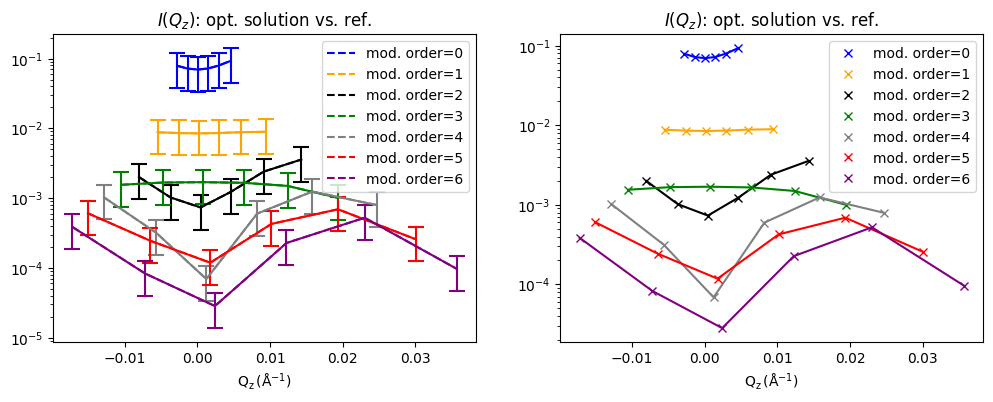

In [23]:
# Optimized solution vs. reference.
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
for i in range(config.dimqxbranch):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intopt[:,i]
    plt.errorbar(qzarray, intrefarray, yerr=uncertainarray, fmt='-', elinewidth=1.5, capsize=6, capthick=1.5,color=colorarray[i])
    plt.plot(qzarray, intmodarray,'--', markersize=5, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: opt. solution vs. ref.')
plt.legend()

plt.subplot(1,2,2)
for i in range(intref.shape[1]):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intopt[:,i]
    plt.plot(qzarray, intrefarray,'-', color=colorarray[i])
    plt.plot(qzarray, intmodarray,'x', markersize=6, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: opt. solution vs. ref.')
plt.legend()

plt.show()

In [24]:
# Relative error report:
print("Relative error report:")
rltverrarray=[]
for i in range(config.dimqxbranch):
    array1=intref[:,i]
    array2=intopt[:,i]
    rltverr=np.linalg.norm(array1-array2)/np.linalg.norm(array1)
    rltverrarray.append(rltverr)
    print(f"relative error of the {i+1}th peak, {rltverr:.2f}")
print(f"Overall relative error: {np.mean(rltverrarray):.2f}")